In [1]:
# Cell 1: 只加载 overlay，不加载 xmodel
import sys
sys.path.append('/usr/lib/python3/site-packages')
import os, numpy as np
from pynq_dpu import DpuOverlay

WORK_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae'
overlay = DpuOverlay(os.path.join(WORK_DIR, 'dpu.bit'))
print("✅ Overlay OK")

✅ Overlay OK


In [ ]:
# Cell 2: 只加载 Encoder，不运行推理
import vart, xir

def get_dpu_subgraph(xmodel_path):
    graph = xir.Graph.deserialize(xmodel_path)
    root = graph.get_root_subgraph()
    children = root.toposort_child_subgraph()
    dpu_subgraphs = [s for s in children
                     if s.has_attr("device") and s.get_attr("device").upper() == "DPU"]
    return graph, dpu_subgraphs[0]

enc_graph, enc_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'encoder_zcu111_700x500.xmodel'))
enc_runner = vart.Runner.create_runner(enc_subgraph, "run")
enc_in_tensors  = enc_runner.get_input_tensors()
enc_out_tensors = enc_runner.get_output_tensors()
print("✅ Encoder runner OK")
print(f"   输入 shape: {tuple(enc_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(enc_out_tensors[0].dims)}")

IndexError: list index out of range

In [3]:
# Cell 3: 只做 fix_point，不运行推理
def get_fixpoint_scale(tensors):
    scales = []
    for t in tensors:
        try:
            fp = t.get_attr("fix_point")
            scales.append(2 ** (-fp))
            print(f"  {t.name}: fix_point={fp}, scale={2**(-fp):.6f}")
        except:
            scales.append(1.0)
            print(f"  {t.name}: 无fix_point, scale=1.0")
    return scales

enc_in_scales  = get_fixpoint_scale(enc_in_tensors)
enc_out_scales = get_fixpoint_scale(enc_out_tensors)
print("✅ fix_point OK")

  EncoderWrapper__input_0_fix: fix_point=6, scale=0.015625
  EncoderWrapper__EncoderWrapper_Conv2d_pre_quantization_conv__ret_fix: fix_point=6, scale=0.015625
✅ fix_point OK


In [12]:
# Cell 4: 只做图片预处理
import cv2
img_bgr = cv2.imread(os.path.join(WORK_DIR, 'test.png'))
# img_bgr = cv2.imread(os.path.join(WORK_DIR, 'test2.jpg'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_small = cv2.resize(img_rgb, (700,500), interpolation=cv2.INTER_LINEAR)
input_fp32 = (img_small.astype(np.float32)/255.0 - 0.5) / 0.5
input_fp32 = input_fp32[np.newaxis]
print(f"✅ 预处理 OK, shape={input_fp32.shape}")

✅ 预处理 OK, shape=(1, 500, 700, 3)


In [13]:
# Cell 5: 只准备 buffer，不执行 execute_async
enc_input_shape  = tuple(enc_in_tensors[0].dims)
enc_output_shape = tuple(enc_out_tensors[0].dims)
enc_in_buf  = [np.empty(enc_input_shape,  dtype=np.int8, order='C')]
enc_out_buf = [np.empty(enc_output_shape, dtype=np.int8, order='C')]
enc_in_buf[0][...] = np.clip(
    np.round(input_fp32 / enc_in_scales[0]), -128, 127
).astype(np.int8)
print(f"✅ Buffer 准备 OK")
print(f"   enc_in_buf  dtype={enc_in_buf[0].dtype}, shape={enc_in_buf[0].shape}")
print(f"   enc_out_buf dtype={enc_out_buf[0].dtype}, shape={enc_out_buf[0].shape}")

✅ Buffer 准备 OK
   enc_in_buf  dtype=int8, shape=(1, 500, 700, 3)
   enc_out_buf dtype=int8, shape=(1, 125, 175, 64)


In [14]:
# Cell 6: 执行encoder，单独执行
print("执行前...")
job_id = enc_runner.execute_async(enc_in_buf, enc_out_buf)
print(f"job_id={job_id}, 等待完成...")
enc_runner.wait(job_id)
print("✅ Encoder 推理完成！")

执行前...
job_id=(1, 0), 等待完成...
✅ Encoder 推理完成！


In [15]:
# Cell 7: 加载 Decoder runner
dec_graph, dec_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'decoder_zcu111_700x500.xmodel'))
dec_runner = vart.Runner.create_runner(dec_subgraph, "run")
dec_in_tensors  = dec_runner.get_input_tensors()
dec_out_tensors = dec_runner.get_output_tensors()
dec_in_scales  = get_fixpoint_scale(dec_in_tensors)
dec_out_scales = get_fixpoint_scale(dec_out_tensors)
print("✅ Decoder runner OK")
print(f"   输入 shape: {tuple(dec_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(dec_out_tensors[0].dims)}")

  DecoderWrapper__input_0_fix: fix_point=5, scale=0.031250
  DecoderWrapper__DecoderWrapper_Decoder_decoder__Sequential_inverse_conv_stack__ConvTranspose2d_4__ret_fix: fix_point=7, scale=0.007812
✅ Decoder runner OK
   输入 shape: (1, 125, 175, 64)
   输出 shape: (1, 500, 700, 3)


In [16]:
# Cell 8: 反量化 Encoder 输出 + VectorQuantizer
enc_out_scale = enc_out_scales[0]
z_e = enc_out_buf[0].astype(np.float32) * enc_out_scale
print(f"✅ z_e shape={z_e.shape}, 范围=[{z_e.min():.3f}, {z_e.max():.3f}]")

# 加载 codebook
codebook = np.load(os.path.join(WORK_DIR, 'codebook.npy')).astype(np.float32)
print(f"✅ codebook shape={codebook.shape}")

def vector_quantize(z_e_nhwc, codebook):
    N, H, W, C = z_e_nhwc.shape
    z_flat = z_e_nhwc.reshape(-1, C).astype(np.float32)
    dist = (
        np.sum(z_flat**2, axis=1, keepdims=True)
        + np.sum(codebook**2, axis=1)
        - 2.0 * z_flat @ codebook.T
    )
    indices = np.argmin(dist, axis=1)
    z_q = codebook[indices].reshape(N, H, W, C)
    return z_q, indices.reshape(H, W)

z_q, indices = vector_quantize(z_e, codebook)
print(f"✅ VQ 完成，z_q shape={z_q.shape}")
print(f"   indices 范围: [{indices.min()}, {indices.max()}]")

✅ z_e shape=(1, 125, 175, 64), 范围=[-2.000, 1.984]
✅ codebook shape=(512, 64)
✅ VQ 完成，z_q shape=(1, 125, 175, 64)
   indices 范围: [6, 511]


In [17]:
# Cell 9: Decoder 推理
dec_input_shape  = tuple(dec_in_tensors[0].dims)
dec_output_shape = tuple(dec_out_tensors[0].dims)
dec_in_buf  = [np.empty(dec_input_shape,  dtype=np.int8, order='C')]
dec_out_buf = [np.empty(dec_output_shape, dtype=np.int8, order='C')]

dec_in_buf[0][...] = np.clip(
    np.round(z_q / dec_in_scales[0]), -128, 127
).astype(np.int8)

print("执行 Decoder 前...")
job_id = dec_runner.execute_async(dec_in_buf, dec_out_buf)
print(f"job_id={job_id}, 等待完成...")
dec_runner.wait(job_id)
print("✅ Decoder 推理完成！")

output = dec_out_buf[0].astype(np.float32) * dec_out_scales[0]
print(f"✅ output shape={output.shape}, 范围=[{output.min():.3f}, {output.max():.3f}]")

执行 Decoder 前...
job_id=(1, 0), 等待完成...
✅ Decoder 推理完成！
✅ output shape=(1, 500, 700, 3), 范围=[-1.000, 0.875]


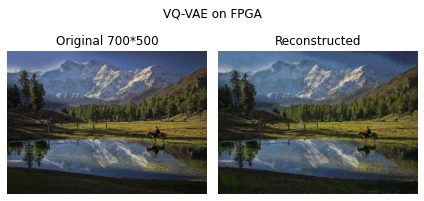

✅ 完成！结果保存至 result.png


In [18]:
# Cell 10: 显示结果
import matplotlib.pyplot as plt

original  = cv2.resize(
    cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'test.png')), cv2.COLOR_BGR2RGB),
    (700,500))
    # cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'test2.jpg')), cv2.COLOR_BGR2RGB),
    # (700,500))

recon = output[0] * 0.5 + 0.5
recon = np.clip(recon, 0.0, 1.0)
recon = (recon * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original);  axes[0].set_title('Original 700*500'); axes[0].axis('off')
axes[1].imshow(recon);     axes[1].set_title('Reconstructed');  axes[1].axis('off')
plt.suptitle('VQ-VAE on FPGA', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result.png'), dpi=300)
plt.show()
print("✅ 完成！结果保存至 result.png")


📊 图像质量评估（原图 vs 重建图）
   SSIM : 0.6086
   PSNR : 23.89 dB


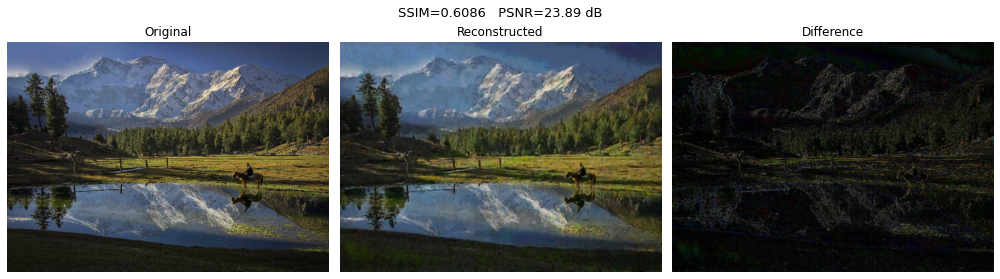

✅ 保存至 result_metrics.png


In [19]:
# Cell 11: 计算 SSIM 和 PSNR
from skimage.metrics import structural_similarity as ssim_func

def calculate_metrics(original_uint8, recon_uint8):
    img1 = original_uint8.astype(np.float32) / 255.0
    img2 = recon_uint8.astype(np.float32)    / 255.0

    ssim_value = ssim_func(img1, img2,
                           multichannel=True,
                           data_range=1.0,
                           win_size=7)

    mse = np.mean((img1 - img2) ** 2)
    psnr_value = float('inf') if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

    return ssim_value, psnr_value


ssim_val, psnr_val = calculate_metrics(original, recon)

print(f"\n📊 图像质量评估（原图 vs 重建图）")
print(f"   SSIM : {ssim_val:.4f}")
print(f"   PSNR : {psnr_val:.2f} dB")

# 差异图
diff      = np.abs(original.astype(np.float32) - recon.astype(np.float32))
diff_norm = (diff / diff.max() * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(original);   axes[0].set_title('Original');      axes[0].axis('off')
axes[1].imshow(recon);      axes[1].set_title('Reconstructed'); axes[1].axis('off')
axes[2].imshow(diff_norm);  axes[2].set_title('Difference');    axes[2].axis('off')
plt.suptitle(f'SSIM={ssim_val:.4f}   PSNR={psnr_val:.2f} dB', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result_metrics.png'), dpi=300)
plt.show()
print("✅ 保存至 result_metrics.png")

原图尺寸: 2000×1331
裁剪后尺寸: 1984×1312，共 2542 个块
  处理块 2541/2542 ...
✅ 全部 2542 个块处理完成


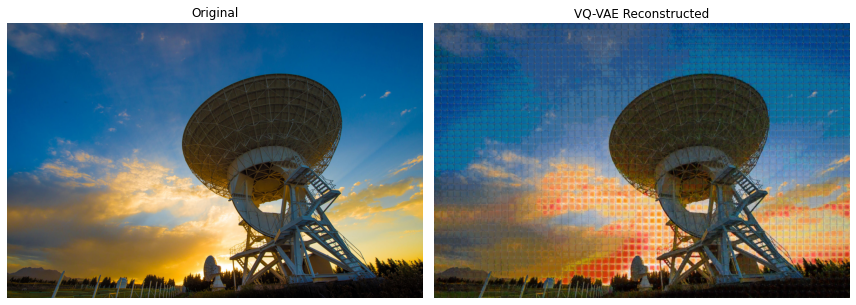

✅ 保存至 result_large.png


In [25]:
# # Cell 12: 分块处理大图
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# def process_large_image(img_path, patch_size=32):
#     """
#     将大图切成 patch_size×patch_size 的块逐块推理，再拼回
#     """
#     # 读取原图
#     img_bgr = cv2.imread(img_path)
#     img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#     H, W, _ = img_rgb.shape
#     print(f"原图尺寸: {W}×{H}")

#     # 裁剪为 patch_size 的整数倍
#     H_crop = (H // patch_size) * patch_size
#     W_crop = (W // patch_size) * patch_size
#     img_crop = img_rgb[:H_crop, :W_crop]
#     print(f"裁剪后尺寸: {W_crop}×{H_crop}，共 {(H_crop//patch_size)*(W_crop//patch_size)} 个块")

#     # 输出画布
#     output_img = np.zeros_like(img_crop, dtype=np.uint8)

#     n_h = H_crop // patch_size
#     n_w = W_crop // patch_size
#     total = n_h * n_w

#     for i in range(n_h):
#         for j in range(n_w):
#             idx = i * n_w + j
#             if idx % 10 == 0:
#                 print(f"  处理块 {idx+1}/{total} ...", end='\r')

#             # 取出 patch
#             patch = img_crop[i*patch_size:(i+1)*patch_size,
#                              j*patch_size:(j+1)*patch_size]

#             # 预处理
#             arr = patch.astype(np.float32) / 255.0
#             arr = (arr - 0.5) / 0.5
#             inp = arr[np.newaxis]   # (1,32,32,3)

#             # Encoder
#             enc_in_buf[0][...] = np.clip(
#                 np.round(inp / enc_in_scales[0]), -128, 127
#             ).astype(np.int8)
#             job = enc_runner.execute_async(enc_in_buf, enc_out_buf)
#             enc_runner.wait(job)

#             # VectorQuantizer
#             z_e = enc_out_buf[0].astype(np.float32) * enc_out_scales[0]
#             z_q, _ = vector_quantize(z_e, codebook)

#             # Decoder
#             dec_in_buf[0][...] = np.clip(
#                 np.round(z_q / dec_in_scales[0]), -128, 127
#             ).astype(np.int8)
#             job = dec_runner.execute_async(dec_in_buf, dec_out_buf)
#             dec_runner.wait(job)

#             # 反量化
#             out = dec_out_buf[0].astype(np.float32) * dec_out_scales[0]
#             out = out[0] * 0.5 + 0.5
#             out = np.clip(out, 0.0, 1.0)
#             out = (out * 255).astype(np.uint8)

#             # 写回画布
#             output_img[i*patch_size:(i+1)*patch_size,
#                        j*patch_size:(j+1)*patch_size] = out

#     print(f"\n✅ 全部 {total} 个块处理完成")
#     return img_crop, output_img

# # 执行
# original_crop, result_large = process_large_image(
#     os.path.join(WORK_DIR, 'test2.jpg'), patch_size=32)

# # 显示
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# axes[0].imshow(original_crop); axes[0].set_title('Original'); axes[0].axis('off')
# axes[1].imshow(result_large);  axes[1].set_title('VQ-VAE Reconstructed'); axes[1].axis('off')
# plt.tight_layout()
# plt.savefig(os.path.join(WORK_DIR, 'result_large.png'), dpi=150)
# plt.show()
# print("✅ 保存至 result_large.png")